# 변수 보완 및 모델 선택

`feature_engineering_stepwise_selection`의 Stepwise 변수(27개, AUC 0.825)에서 출발해, 결과·SHAP·오답 분석을 보며 **수동으로 변수를 보완**하고 알고리즘을 비교합니다.

**처리 순서**
- 3. 발라드 변수 보완
- 4. 다른 모델 비교
- 5. CatBoost + Optuna 파라미터 적용
- 6. FP 개선을 위한 파생변수 추가

최종 모델은 `final_model`에서 다룹니다.

# 0. 데이터 불러오기
<small>중복 제거가 끝난 데이터(`data(drop_duplicated).csv`)를 불러옵니다.</small>

In [1]:
# 데이터 불러오기: 다른 노트북(01·02·04)과 같은 입력 파일
from pathlib import Path
import pandas as pd

DATA_FILE = Path("../data/data(drop_duplicated).csv")      # 전처리(deduplication)가 만든 분석용 데이터

df_final = pd.read_csv(DATA_FILE)
drop_df = df_final.copy()      # 아래 코드는 drop_df 이름으로 이어짐. 이상치 제외 없이 2,043곡 전체를 사용(성능 수치 유지)

# 3. 발라드 변수 보완
<small>발라드 장르 곡의 성공 여부를 잘 포착하지 못하는 문제를 발견해, 발라드 관련 파생변수를 추가하고 다시 모델을 돌립니다.</small>

[ 오답 패턴 기반 파생변수 확인 ]
ballad_score - mean: 0.0017, std: 0.0019
solo_ballad  - mean: 0.0019, std: 0.0021
is_version   - 버전곡 수: 65개 / 전체 2043개

데이터 shape    : (2043, 30)
Hit  (≥100만뷰) : 1259개  (61.63%)
Non-Hit         : 784개  (38.37%)
사용 피처 수    : 30

[CatBoost 결과]
Accuracy : 0.7739
Precision: 0.7924
Recall   : 0.8578
F1       : 0.8238
AUC      : 0.8298

Confusion Matrix  →  TN=501, FP=283, FN=179, TP=1080


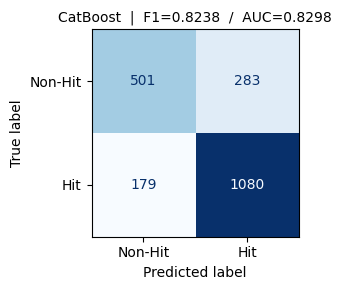

>> Saved: catboost_final_cm.png

[SHAP 분석 중...]


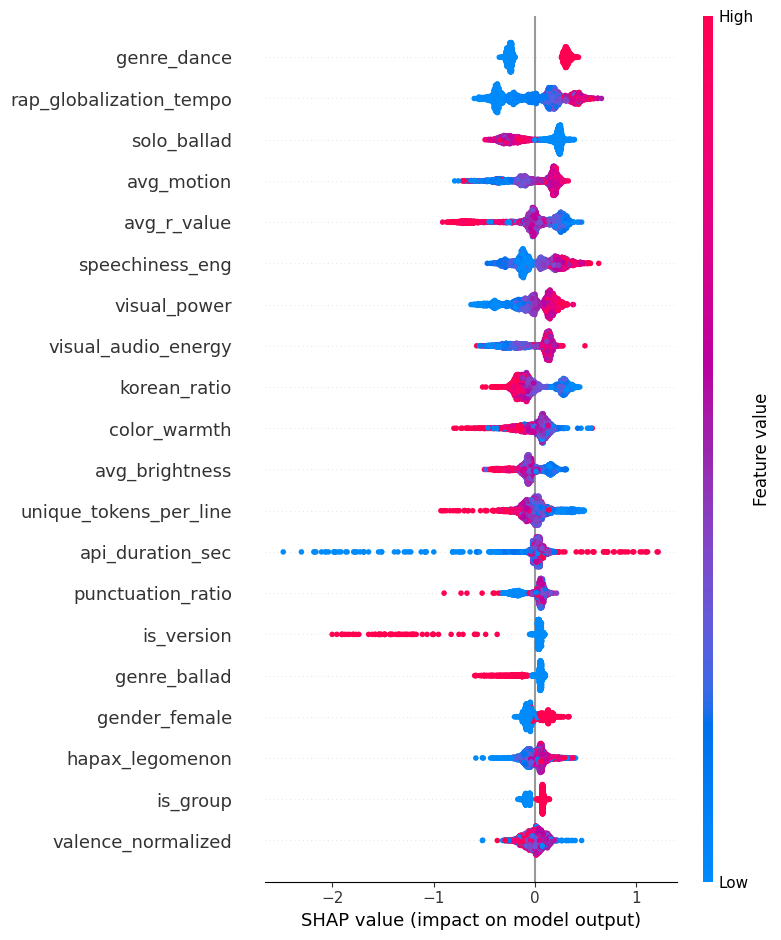

>> Saved: shap_beeswarm.png


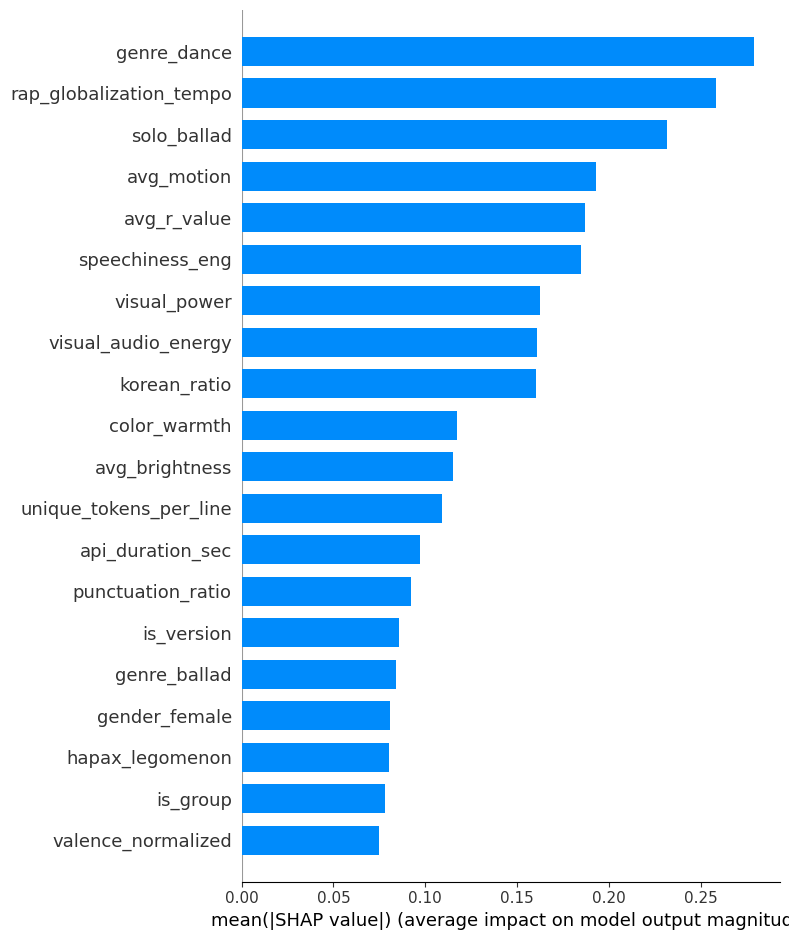

>> Saved: shap_bar.png

[SHAP 특징 중요도 상위 15위]
                feature  mean_shap
            genre_dance   0.279111
rap_globalization_tempo   0.258057
            solo_ballad   0.231302
             avg_motion   0.193081
            avg_r_value   0.186946
        speechiness_eng   0.184931
           visual_power   0.162510
    visual_audio_energy   0.160767
           korean_ratio   0.160210
           color_warmth   0.117150
         avg_brightness   0.114846
 unique_tokens_per_line   0.109109
       api_duration_sec   0.097010
      punctuation_ratio   0.092086
             is_version   0.085633

>> Saved: catboost_final_result.csv
>> Saved: shap_importance.csv

[FP 곡: 실제 Non-Hit → 예측 Hit  |  총 283개]
                                             songName                                                                                                         artists  api_view_count                                         url  y_true  y_pred   y_prob
                                     

In [18]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from catboost import CatBoostClassifier
import shap

# ════════════════════════════════════════════════════════════
# 1. 파생변수 생성
# ════════════════════════════════════════════════════════════

# ── 기존 파생변수 ──
drop_df['speechiness_eng']         = drop_df['token_count'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['rap_globalization_tempo'] = drop_df['speechiness'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['visual_power']            = drop_df['avg_motion'] * drop_df['energy']
drop_df['sentiment_intensity']     = drop_df['sentiment_compound'].abs() * drop_df['punctuation_ratio']
drop_df['global_emotion']          = drop_df['sentiment_compound'] * drop_df['tempo']
drop_df['ballad_global']           = (1 / (drop_df['tempo'] + 1)) * drop_df['english_ratio'] * drop_df['unique_tokens_per_line']

# ── Stepwise 추가 파생변수: 시각 ──
drop_df['color_warmth']           = drop_df['avg_r_value'] - drop_df['avg_b_value']
drop_df['color_saturation_proxy'] = (drop_df['avg_r_value'] + drop_df['avg_g_value'] + drop_df['avg_b_value']) / 3
drop_df['visual_audio_energy']    = drop_df['avg_motion'] * drop_df['loudness'].abs()

# ── Stepwise 추가 파생변수: 음향 ──
drop_df['sound_impact']           = drop_df['energy'] * drop_df['loudness'].abs()
drop_df['acoustic_contrast']      = (1 - drop_df['acoustic_score']) * drop_df['energy']

# ── Stepwise 추가 파생변수: 가사 ──
drop_df['lyric_repetition']       = drop_df['repeated_token_ratio'] * drop_df['line_count']
drop_df['lyric_intimacy']         = drop_df['pronoun_frequency'] * drop_df['sentiment_compound'].abs()
drop_df['lyric_complexity']       = drop_df['compression_rate'] * drop_df['avg_token_length']
drop_df['pop_sentiment_index']    = drop_df['english_ratio'] * drop_df['valence_normalized'] * drop_df['tempo']

# ── 오답 패턴 기반 파생변수 ──
# ① 발라드 감성 지수: 느린 템포 × 한국어 가사 × 감성 강도
drop_df['ballad_score'] = (
    (1 / (drop_df['tempo'] + 1)) *
    drop_df['korean_ratio'] *
    drop_df['sentiment_compound'].abs()
)

# ② 솔로 발라드 지수: 솔로 × 느린 템포 × 낮은 valence
# (참고) solo_ballad는 실험 과정에서 감성 항목을 바꿨습니다: 3단계 (1 - valence) → 5단계 |sentiment_compound| → final_model sentiment_negative
drop_df['solo_ballad'] = (
    (1 - drop_df['is_group']) *
    (1 / (drop_df['tempo'] + 1)) *
    (1 - drop_df['valence_normalized'].clip(0, 1))
)

# ③ 버전 여부: 리믹스/영어버전 등 파생 버전 FP 감소 목적
drop_df['is_version'] = drop_df['songName'].str.contains(
    r'remix|ver\.|version|repack|inst\.|english|korean|2100|2023|2024|2025',
    case=False, regex=True
).astype(int)

print("[ 오답 패턴 기반 파생변수 확인 ]")
print(f"ballad_score - mean: {drop_df['ballad_score'].mean():.4f}, std: {drop_df['ballad_score'].std():.4f}")
print(f"solo_ballad  - mean: {drop_df['solo_ballad'].mean():.4f}, std: {drop_df['solo_ballad'].std():.4f}")
print(f"is_version   - 버전곡 수: {drop_df['is_version'].sum()}개 / 전체 {len(drop_df)}개")


# ════════════════════════════════════════════════════════════
# 2. 원핫 인코딩
# ════════════════════════════════════════════════════════════

if 'genie_genre' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['genie_genre'], prefix='genre', drop_first=True)
if 'gender' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['gender'], prefix='gender')


# ════════════════════════════════════════════════════════════
# 3. 피처 정의 (총 30개)
# ════════════════════════════════════════════════════════════

FEATURES = [
    # ── 기본 23개 ──
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_여성', 'gender_혼성',
    'global_emotion', 'speechiness_eng',
    'genre_댄스', 'genre_발라드', 'genre_일렉트로니카',
    'genre_락', 'genre_랩/힙합', 'genre_인디', 'genre_팝',
    # ── Stepwise 추가 5개 ──
    'color_warmth', 'avg_r_value', 'visual_audio_energy',
    'avg_g_value', 'loudness',
    # ── 오답 패턴 기반 추가 3개 ──
    'ballad_score', 'solo_ballad', 'is_version',
]

FEATURES_EN = [
    # ── 기본 23개 ──
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_female', 'gender_mixed',
    'global_emotion', 'speechiness_eng',
    'genre_dance', 'genre_ballad', 'genre_electronic',
    'genre_rock', 'genre_rap_hiphop', 'genre_indie', 'genre_pop',
    # ── Stepwise 추가 5개 ──
    'color_warmth', 'avg_r_value', 'visual_audio_energy',
    'avg_g_value', 'loudness',
    # ── 오답 패턴 기반 추가 3개 ──
    'ballad_score', 'solo_ballad', 'is_version',
]

# 실제 컬럼 존재 여부 필터링
FEATURES    = [f for f in FEATURES if f in drop_df.columns]
FEATURES_EN = FEATURES_EN[:len(FEATURES)]

X = drop_df[FEATURES].copy()
y = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print(f"데이터 shape    : {X.shape}")
print(f"Hit  (≥100만뷰) : {int((y==1).sum())}개  ({round(y.mean()*100, 2)}%)")
print(f"Non-Hit         : {int((y==0).sum())}개  ({round((1-y.mean())*100, 2)}%)")
print(f"사용 피처 수    : {len(FEATURES)}")
print("=" * 60)


# ════════════════════════════════════════════════════════════
# 4. CatBoost 학습 & 교차검증
# ════════════════════════════════════════════════════════════

best_model = CatBoostClassifier(
    iterations=          772,
    learning_rate=       0.019113930760271142,
    depth=               4,
    l2_leaf_reg=         2.2251588705304837,
    bagging_temperature= 0.21762189130109433,
    random_strength=     0.15009890934829523,
    border_count=        142,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=0,
)

y_pred = cross_val_predict(best_model, X, y, cv=cv, method='predict')
y_prob = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec  = recall_score(y, y_pred)
f1   = f1_score(y, y_pred)
auc  = roc_auc_score(y, y_prob)

print("\n[CatBoost 결과]")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"\nConfusion Matrix  →  TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("=" * 60)


# ════════════════════════════════════════════════════════════
# 5. Confusion Matrix 시각화
# ════════════════════════════════════════════════════════════

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CatBoost  |  F1={f1:.4f}  /  AUC={auc:.4f}", fontsize=10)
plt.tight_layout()
plt.savefig('catboost_final_cm.png', dpi=120)
plt.show()
print(">> Saved: catboost_final_cm.png")


# ════════════════════════════════════════════════════════════
# 6. SHAP 분석
# ════════════════════════════════════════════════════════════

print("\n[SHAP 분석 중...]")
best_model.fit(X, y)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

# beeswarm
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X, feature_names=FEATURES_EN, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120)
plt.show()
print(">> Saved: shap_beeswarm.png")

# bar
plt.figure(figsize=(9, 9))
shap.summary_plot(shap_values, X, feature_names=FEATURES_EN, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120)
plt.show()
print(">> Saved: shap_bar.png")

shap_importance = pd.DataFrame({
    'feature': FEATURES_EN,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\n[SHAP 특징 중요도 상위 15위]")
print(shap_importance.head(15).to_string(index=False))


# ════════════════════════════════════════════════════════════
# 7. 결과 저장
# ════════════════════════════════════════════════════════════

pd.DataFrame([{
    '모델': 'CatBoost_final',
    'Accuracy':  round(acc,  4),
    'Precision': round(prec, 4),
    'Recall':    round(rec,  4),
    'F1':        round(f1,   4),
    'AUC':       round(auc,  4),
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
}]).to_csv('catboost_final_result.csv', index=False)
print("\n>> Saved: catboost_final_result.csv")

shap_importance.to_csv('shap_importance.csv', index=False)
print(">> Saved: shap_importance.csv")


# ════════════════════════════════════════════════════════════
# 8. FP / FN 오답 분석
# ════════════════════════════════════════════════════════════

result_df = drop_df[['songName', 'artists', 'api_view_count', 'url']].copy()
result_df['y_true'] = y.values
result_df['y_pred'] = y_pred
result_df['y_prob'] = y_prob

fp_df = result_df[(result_df['y_true'] == 0) & (result_df['y_pred'] == 1)].sort_values('y_prob', ascending=False)
fn_df = result_df[(result_df['y_true'] == 1) & (result_df['y_pred'] == 0)].sort_values('y_prob', ascending=True)

print(f"\n[FP 곡: 실제 Non-Hit → 예측 Hit  |  총 {len(fp_df)}개]")
print(fp_df.to_string(index=False))

print(f"\n[FN 곡: 실제 Hit → 예측 Non-Hit  |  총 {len(fn_df)}개]")
print(fn_df.to_string(index=False))

fp_df.to_csv('fp_songs.csv', index=False)
fn_df.to_csv('fn_songs.csv', index=False)
print("\n>> Saved: fp_songs.csv, fn_songs.csv")

# 4. 다른 모델 비교
<small>가장 성능이 잘 나온 변수 세트를 고정하고, 여러 분류 모델(로지스틱회귀·랜덤포레스트·XGBoost·LightGBM 등)에 돌려 비교합니다.</small>

Model                        Acc   Prec    Rec     F1    AUC
LogisticRegression        0.7416 0.7598 0.8491 0.8020 0.7796
RidgeClassifier           0.7621 0.7795 0.8562 0.8160    N/A
SGDClassifier             0.6295 0.6846 0.7395 0.7110    N/A
PassiveAggressive         0.6304 0.6975 0.7069 0.7022    N/A
LinearSVC                 0.7416 0.7533 0.8634 0.8046    N/A
LDA                       0.7621 0.7815 0.8523 0.8153 0.8139
QDA                       0.6843 0.7924 0.6608 0.7207 0.7215
GaussianNB                0.7381 0.7747 0.8110 0.7924 0.7835
BernoulliNB               0.7288 0.7809 0.7784 0.7796 0.7770
DecisionTree              0.6897 0.7443 0.7562 0.7502 0.6695
ExtraTree                 0.6716 0.7330 0.7347 0.7338 0.6524
RandomForest              0.7606 0.7810 0.8499 0.8140 0.8145
ExtraTrees                0.7641 0.7850 0.8499 0.8162 0.8142
GradientBoosting          0.7553 0.7826 0.8348 0.8078 0.8085
HistGradientBoosting      0.7494 0.7756 0.8348 0.8041 0.8047
AdaBoost                

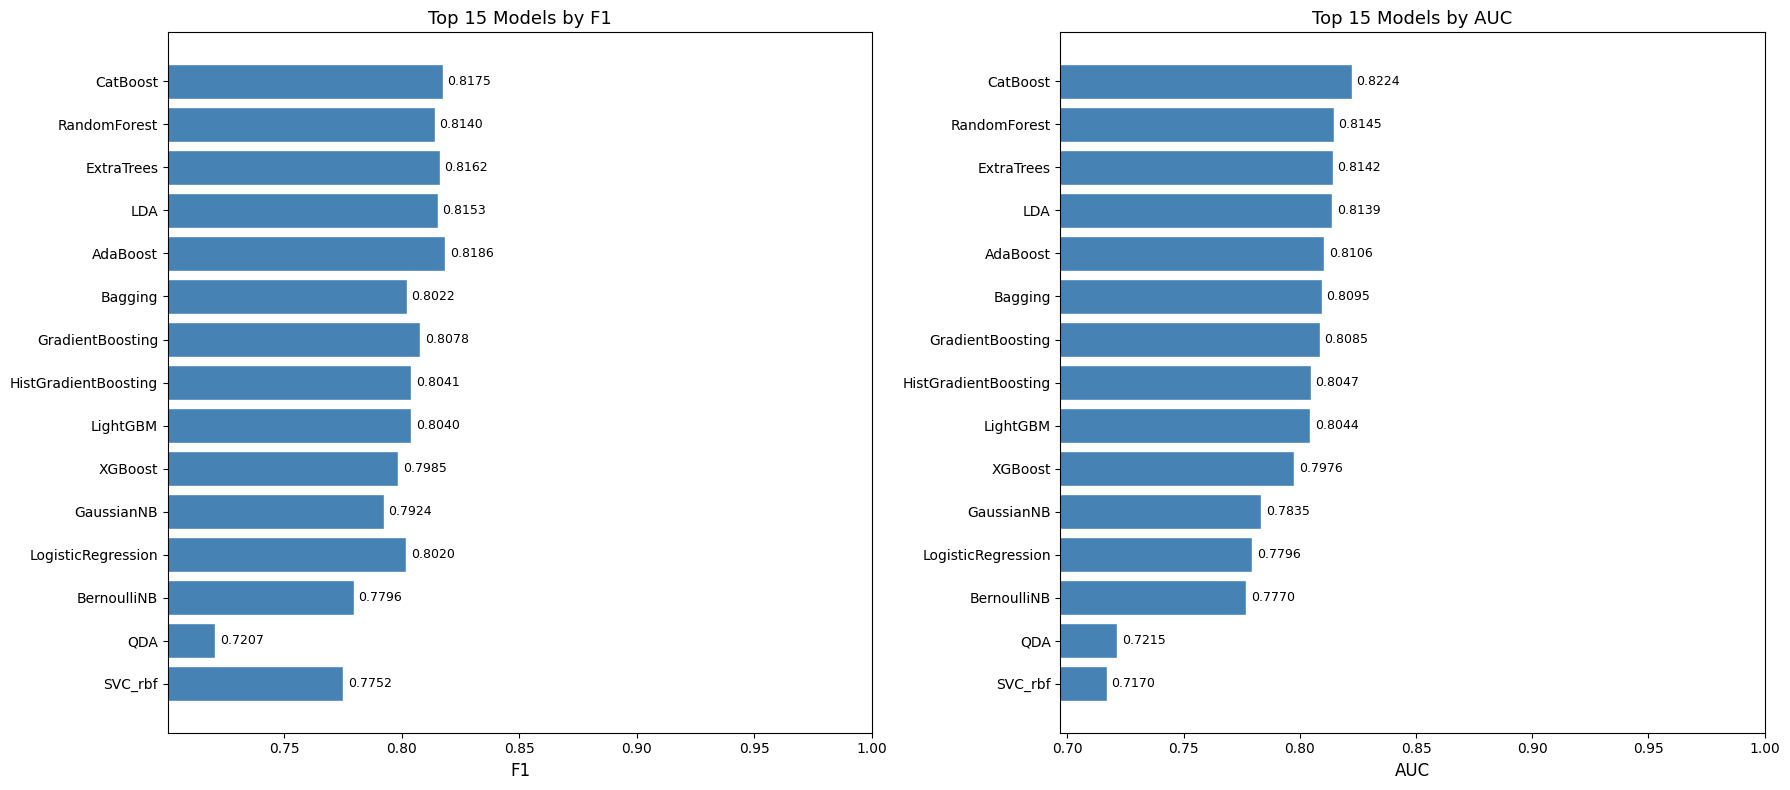

>> Saved: model_comparison.png


In [24]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# ── 사이킷런 모델 ──
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    PassiveAggressiveClassifier
)
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.neural_network import MLPClassifier

# ── 외부 라이브러리 ──
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ════════════════════════════════════════════════════════════
# 데이터 준비 (파생변수 & 원핫인코딩은 이전 셀에서 완료된 상태)
# ════════════════════════════════════════════════════════════

X = drop_df[FEATURES].copy()
y = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ════════════════════════════════════════════════════════════
# 모델 정의 (총 25개)
# ════════════════════════════════════════════════════════════

models = {
    # ── 선형 계열 ──
    'LogisticRegression':        LogisticRegression(max_iter=1000, random_state=42),
    'RidgeClassifier':           RidgeClassifier(),
    'SGDClassifier':             SGDClassifier(random_state=42, max_iter=1000),
    'PassiveAggressive':         PassiveAggressiveClassifier(random_state=42, max_iter=1000),
    'LinearSVC':                 LinearSVC(random_state=42, max_iter=2000),

    # ── 판별 분석 ──
    'LDA':                       LinearDiscriminantAnalysis(),
    'QDA':                       QuadraticDiscriminantAnalysis(),

    # ── 나이브 베이즈 ──
    'GaussianNB':                GaussianNB(),
    'BernoulliNB':               BernoulliNB(),

    # ── 트리 계열 ──
    'DecisionTree':              DecisionTreeClassifier(random_state=42),
    'ExtraTree':                 ExtraTreeClassifier(random_state=42),

    # ── 앙상블 계열 ──
    'RandomForest':              RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'ExtraTrees':                ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting':          GradientBoostingClassifier(n_estimators=300, random_state=42),
    'HistGradientBoosting':      HistGradientBoostingClassifier(random_state=42),
    'AdaBoost':                  AdaBoostClassifier(n_estimators=200, random_state=42),
    'Bagging':                   BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),

    # ── KNN ──
    'KNN_5':                     KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'KNN_11':                    KNeighborsClassifier(n_neighbors=11, n_jobs=-1),

    # ── SVM ──
    'SVC_rbf':                   SVC(kernel='rbf', probability=True, random_state=42),
    'NuSVC':                     NuSVC(probability=True, random_state=42),

    # ── 신경망 ──
    'MLP':                       MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),

    # ── 부스팅 3대장 ──
    'XGBoost':                   XGBClassifier(n_estimators=300, random_state=42,
                                               eval_metric='logloss', verbosity=0, n_jobs=-1),
    'LightGBM':                  LGBMClassifier(n_estimators=300, random_state=42,
                                                verbose=-1, n_jobs=-1),
    'CatBoost':                  CatBoostClassifier(iterations=772,
                                                    learning_rate=0.019113930760271142,
                                                    depth=4,
                                                    l2_leaf_reg=2.2251588705304837,
                                                    bagging_temperature=0.21762189130109433,
                                                    random_strength=0.15009890934829523,
                                                    border_count=142,
                                                    loss_function='Logloss',
                                                    eval_metric='F1',
                                                    random_seed=42,
                                                    verbose=0),
}

# ════════════════════════════════════════════════════════════
# 교차검증 실행
# ════════════════════════════════════════════════════════════

# AUC 불가 모델 (predict_proba 미지원)
NO_PROBA = {'RidgeClassifier', 'SGDClassifier', 'PassiveAggressive', 'LinearSVC'}

results = []
print("=" * 70)
print(f"{'Model':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
print("=" * 70)

for name, model in models.items():
    try:
        y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')

        acc  = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred, zero_division=0)
        rec  = recall_score(y, y_pred)
        f1   = f1_score(y, y_pred)

        if name not in NO_PROBA:
            y_prob = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
            auc    = roc_auc_score(y, y_prob)
        else:
            auc = np.nan

        results.append({
            'Model': name,
            'Accuracy':  round(acc,  4),
            'Precision': round(prec, 4),
            'Recall':    round(rec,  4),
            'F1':        round(f1,   4),
            'AUC':       round(auc,  4) if not np.isnan(auc) else np.nan,
        })
        auc_str = f"{auc:.4f}" if not np.isnan(auc) else "  N/A"
        print(f"{name:<25} {acc:>6.4f} {prec:>6.4f} {rec:>6.4f} {f1:>6.4f} {auc_str:>6}")

    except Exception as e:
        print(f"{name:<25} ERROR: {e}")

print("=" * 70)

# ════════════════════════════════════════════════════════════
# 결과 정리 & 시각화
# ════════════════════════════════════════════════════════════

result_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)

print("\n[ AUC 기준 상위 10개 모델 ]")
print(result_df.head(10).to_string(index=False))

result_df.to_csv('model_comparison.csv', index=False)
print("\n>> Saved: model_comparison.csv")

# ── F1 & AUC 바 차트 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_df = result_df.dropna(subset=['AUC']).head(15)

for ax, metric in zip(axes, ['F1', 'AUC']):
    bars = ax.barh(top_df['Model'][::-1], top_df[metric][::-1], color='steelblue', edgecolor='white')
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Top 15 Models by {metric}', fontsize=13)
    ax.set_xlim(top_df[metric].min() - 0.02, 1.0)
    for bar, val in zip(bars, top_df[metric][::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()
print(">> Saved: model_comparison.png")

# 5. CatBoost + Optuna 파라미터 적용
<small>비교 결과 가장 좋았던 CatBoost에 Optuna로 탐색한 하이퍼파라미터를 적용합니다.</small>

[ 파생변수 생성 완료 ]
ballad_score - mean: 0.0017
solo_ballad  - mean: 0.0016

데이터 shape    : (2043, 29)
Hit  (≥100만뷰) : 1259개  (61.63%)
Non-Hit         : 784개  (38.37%)
사용 피처 수    : 29

[CatBoost 최종 결과]
Accuracy : 0.7655
Precision: 0.7855
Recall   : 0.8523
F1       : 0.8175
AUC      : 0.8224

Confusion Matrix  →  TN=491, FP=293, FN=186, TP=1073


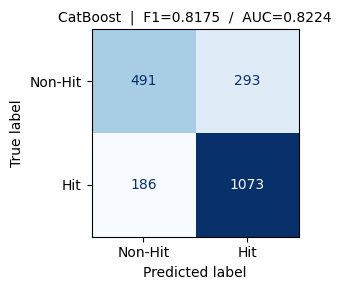

>> Saved: catboost_final_cm.png

[SHAP 분석 중...]


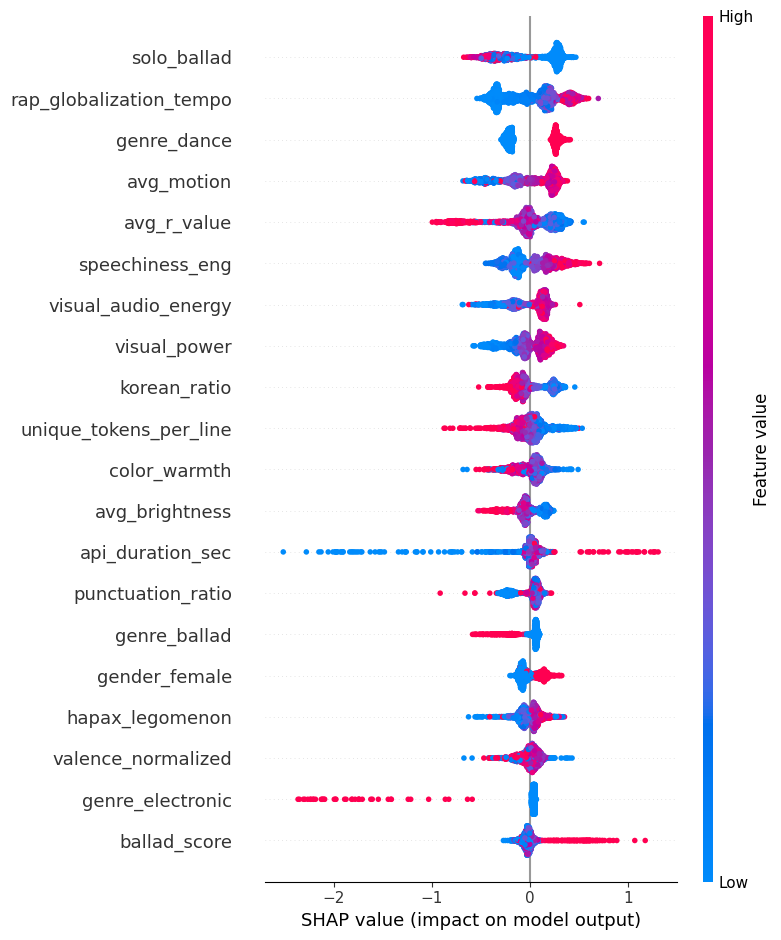

>> Saved: shap_beeswarm.png


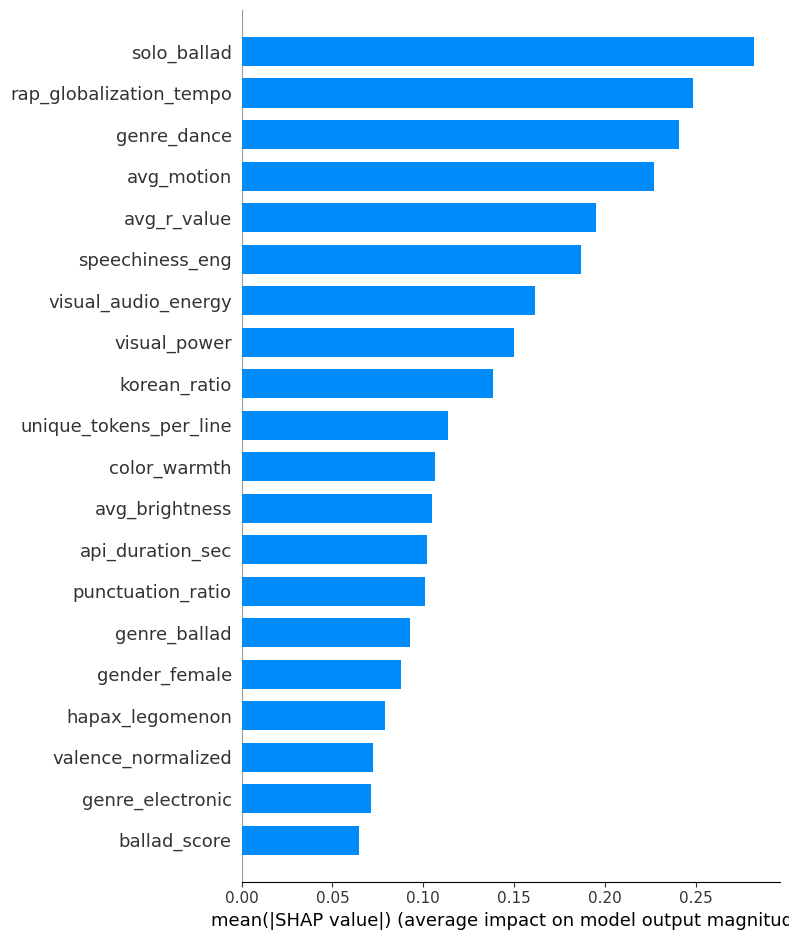

>> Saved: shap_bar.png

[SHAP 특징 중요도 상위 15위]
                feature  mean_shap
            solo_ballad   0.282192
rap_globalization_tempo   0.248581
            genre_dance   0.240818
             avg_motion   0.226829
            avg_r_value   0.195275
        speechiness_eng   0.186541
    visual_audio_energy   0.161432
           visual_power   0.150125
           korean_ratio   0.138562
 unique_tokens_per_line   0.113457
           color_warmth   0.106513
         avg_brightness   0.104817
       api_duration_sec   0.101889
      punctuation_ratio   0.100666
           genre_ballad   0.092951
>> Saved: shap_importance_final.csv
>> Saved: catboost_final_result.csv

[FP 곡: 실제 Non-Hit → 예측 Hit  |  총 293개]
                                             songName                                                                                                                                                    artists  api_view_count                                         url  y_true  y_pre

In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from catboost import CatBoostClassifier
import shap

# ════════════════════════════════════════════════════════════
# 1. 파생변수 생성
# ════════════════════════════════════════════════════════════

# ── 기존 파생변수 ──
drop_df['speechiness_eng']         = drop_df['token_count'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['rap_globalization_tempo'] = drop_df['speechiness'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['visual_power']            = drop_df['avg_motion'] * drop_df['energy']
drop_df['sentiment_intensity']     = drop_df['sentiment_compound'].abs() * drop_df['punctuation_ratio']
drop_df['global_emotion']          = drop_df['sentiment_compound'] * drop_df['tempo']
drop_df['ballad_global']           = (1 / (drop_df['tempo'] + 1)) * drop_df['english_ratio'] * drop_df['unique_tokens_per_line']

# ── Stepwise 추가: 시각 ──
drop_df['color_warmth']           = drop_df['avg_r_value'] - drop_df['avg_b_value']
drop_df['color_saturation_proxy'] = (drop_df['avg_r_value'] + drop_df['avg_g_value'] + drop_df['avg_b_value']) / 3
drop_df['visual_audio_energy']    = drop_df['avg_motion'] * drop_df['loudness'].abs()

# ── Stepwise 추가: 음향 ──
drop_df['sound_impact']           = drop_df['energy'] * drop_df['loudness'].abs()
drop_df['acoustic_contrast']      = (1 - drop_df['acoustic_score']) * drop_df['energy']

# ── Stepwise 추가: 가사 ──
drop_df['lyric_repetition']       = drop_df['repeated_token_ratio'] * drop_df['line_count']
drop_df['lyric_intimacy']         = drop_df['pronoun_frequency'] * drop_df['sentiment_compound'].abs()
drop_df['lyric_complexity']       = drop_df['compression_rate'] * drop_df['avg_token_length']
drop_df['pop_sentiment_index']    = drop_df['english_ratio'] * drop_df['valence_normalized'] * drop_df['tempo']

# ── 오답 패턴 기반 ──
drop_df['ballad_score'] = (
    (1 / (drop_df['tempo'] + 1)) *
    drop_df['korean_ratio'] *
    drop_df['sentiment_compound'].abs()
)
# (참고) 3단계의 (1 - valence) 대신 감성 강도 |sentiment_compound|를 사용합니다. final_model에서는 sentiment_negative(부정 감성)로 다시 바꿨습니다.
drop_df['solo_ballad'] = (
    (1 - drop_df['is_group']) *
    (1 / (drop_df['tempo'] + 1)) *
    drop_df['sentiment_compound'].abs()
)

print("[ 파생변수 생성 완료 ]")
print(f"ballad_score - mean: {drop_df['ballad_score'].mean():.4f}")
print(f"solo_ballad  - mean: {drop_df['solo_ballad'].mean():.4f}")


# ════════════════════════════════════════════════════════════
# 2. 원핫 인코딩
# ════════════════════════════════════════════════════════════

if 'genie_genre' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['genie_genre'], prefix='genre', drop_first=True)
if 'gender' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['gender'], prefix='gender')


# ════════════════════════════════════════════════════════════
# 3. 피처 정의 (총 29개)
# ════════════════════════════════════════════════════════════

FEATURES = [
    # ── 기본 23개 ──
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_여성', 'gender_혼성',
    'global_emotion', 'speechiness_eng',
    'genre_댄스', 'genre_발라드', 'genre_일렉트로니카',
    'genre_락', 'genre_랩/힙합', 'genre_인디', 'genre_팝',
    # ── Stepwise 추가 5개 ──
    'color_warmth', 'avg_r_value', 'visual_audio_energy',
    'avg_g_value', 'loudness',
    # ── 오답 패턴 기반 2개 ──
    'ballad_score', 'solo_ballad',
]

FEATURES_EN = [
    # ── 기본 23개 ──
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_female', 'gender_mixed',
    'global_emotion', 'speechiness_eng',
    'genre_dance', 'genre_ballad', 'genre_electronic',
    'genre_rock', 'genre_rap_hiphop', 'genre_indie', 'genre_pop',
    # ── Stepwise 추가 5개 ──
    'color_warmth', 'avg_r_value', 'visual_audio_energy',
    'avg_g_value', 'loudness',
    # ── 오답 패턴 기반 2개 ──
    'ballad_score', 'solo_ballad',
]

FEATURES    = [f for f in FEATURES if f in drop_df.columns]
FEATURES_EN = FEATURES_EN[:len(FEATURES)]

X = drop_df[FEATURES].copy()
y = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print(f"데이터 shape    : {X.shape}")
print(f"Hit  (≥100만뷰) : {int((y==1).sum())}개  ({round(y.mean()*100, 2)}%)")
print(f"Non-Hit         : {int((y==0).sum())}개  ({round((1-y.mean())*100, 2)}%)")
print(f"사용 피처 수    : {len(FEATURES)}")
print("=" * 60)


# ════════════════════════════════════════════════════════════
# 4. CatBoost 학습 & 교차검증
# ════════════════════════════════════════════════════════════

best_model = CatBoostClassifier(
    iterations=          772,
    learning_rate=       0.019113930760271142,
    depth=               4,
    l2_leaf_reg=         2.2251588705304837,
    bagging_temperature= 0.21762189130109433,
    random_strength=     0.15009890934829523,
    border_count=        142,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=0,
)

y_pred = cross_val_predict(best_model, X, y, cv=cv, method='predict')
y_prob = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec  = recall_score(y, y_pred)
f1   = f1_score(y, y_pred)
auc  = roc_auc_score(y, y_prob)

print("\n[CatBoost 최종 결과]")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"\nConfusion Matrix  →  TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("=" * 60)


# ════════════════════════════════════════════════════════════
# 5. Confusion Matrix 시각화
# ════════════════════════════════════════════════════════════

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CatBoost  |  F1={f1:.4f}  /  AUC={auc:.4f}", fontsize=10)
plt.tight_layout()
plt.savefig('catboost_final_cm.png', dpi=120)
plt.show()
print(">> Saved: catboost_final_cm.png")


# ════════════════════════════════════════════════════════════
# 6. SHAP 분석
# ════════════════════════════════════════════════════════════

print("\n[SHAP 분석 중...]")
best_model.fit(X, y)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X, feature_names=FEATURES_EN, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120)
plt.show()
print(">> Saved: shap_beeswarm.png")

plt.figure(figsize=(9, 9))
shap.summary_plot(shap_values, X, feature_names=FEATURES_EN, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120)
plt.show()
print(">> Saved: shap_bar.png")

shap_importance = pd.DataFrame({
    'feature': FEATURES_EN,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\n[SHAP 특징 중요도 상위 15위]")
print(shap_importance.head(15).to_string(index=False))

shap_importance.to_csv('shap_importance_final.csv', index=False)
print(">> Saved: shap_importance_final.csv")


# ════════════════════════════════════════════════════════════
# 7. 결과 저장
# ════════════════════════════════════════════════════════════

pd.DataFrame([{
    '모델': 'CatBoost_final',
    'Accuracy':  round(acc,  4),
    'Precision': round(prec, 4),
    'Recall':    round(rec,  4),
    'F1':        round(f1,   4),
    'AUC':       round(auc,  4),
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
}]).to_csv('catboost_final_result.csv', index=False)
print(">> Saved: catboost_final_result.csv")


# ════════════════════════════════════════════════════════════
# 8. FP / FN 오답 분석
# ════════════════════════════════════════════════════════════

result_df = drop_df[['songName', 'artists', 'api_view_count', 'url']].copy()
result_df['y_true'] = y.values
result_df['y_pred'] = y_pred
result_df['y_prob'] = y_prob

fp_df = result_df[(result_df['y_true'] == 0) & (result_df['y_pred'] == 1)].sort_values('y_prob', ascending=False)
fn_df = result_df[(result_df['y_true'] == 1) & (result_df['y_pred'] == 0)].sort_values('y_prob', ascending=True)

print(f"\n[FP 곡: 실제 Non-Hit → 예측 Hit  |  총 {len(fp_df)}개]")
print(fp_df.to_string(index=False))

print(f"\n[FN 곡: 실제 Hit → 예측 Non-Hit  |  총 {len(fn_df)}개]")
print(fn_df.to_string(index=False))

fp_df.to_csv('fp_songs_final.csv', index=False)
fn_df.to_csv('fn_songs_final.csv', index=False)
print("\n>> Saved: fp_songs_final.csv, fn_songs_final.csv")

# 6. FP 개선을 위한 파생변수 추가
<small>False Positive(과대예측) 사례를 줄이기 위해 대형그룹 여부·댄스×모션 강도·콜라보 여부 파생변수 3개를 추가합니다.</small>

[ 추가 파생변수 확인 ]
large_group           - 대형그룹 곡 수 : 833개
dance_motion_intensity - mean          : 21.2325
is_collab             - 콜라보 곡 수   : 167개

[ is_collab × Hit 분포 ]
is_hit       0     1   All
is_collab                 
0          706  1170  1876
1           78    89   167
All        784  1259  2043

사용 피처 수: 32개

[CatBoost 결과 - 3개 추가]
Accuracy : 0.7660
Precision: 0.7865
Recall   : 0.8515
F1       : 0.8177
AUC      : 0.8245

Confusion Matrix  →  TN=493, FP=291, FN=187, TP=1072

[ 이전 결과와 비교 ]
버전                            F1    AUC    FP   FN
--------------------------------------------------
기존 29개                    0.8175 0.8224   293  186
신규 32개                    0.8177 0.8245   291  187


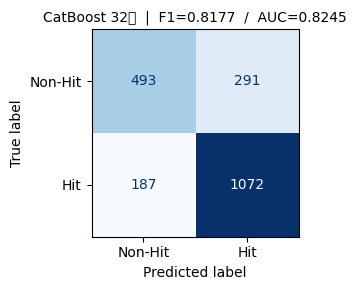


[SHAP 분석 중...]


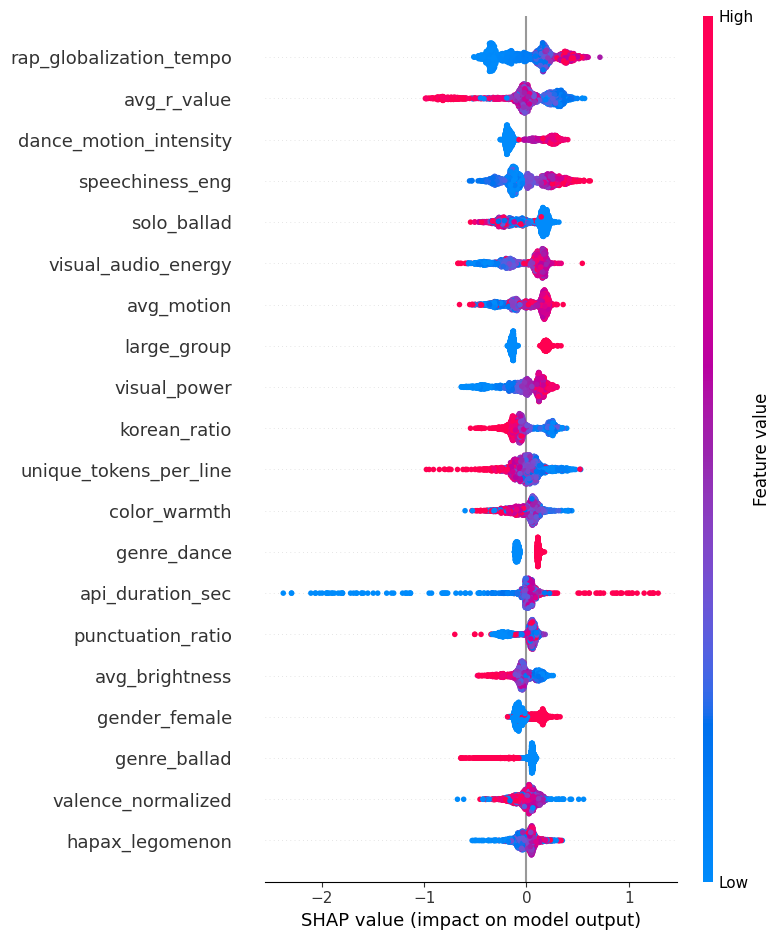

>> Saved: shap_beeswarm_32.png


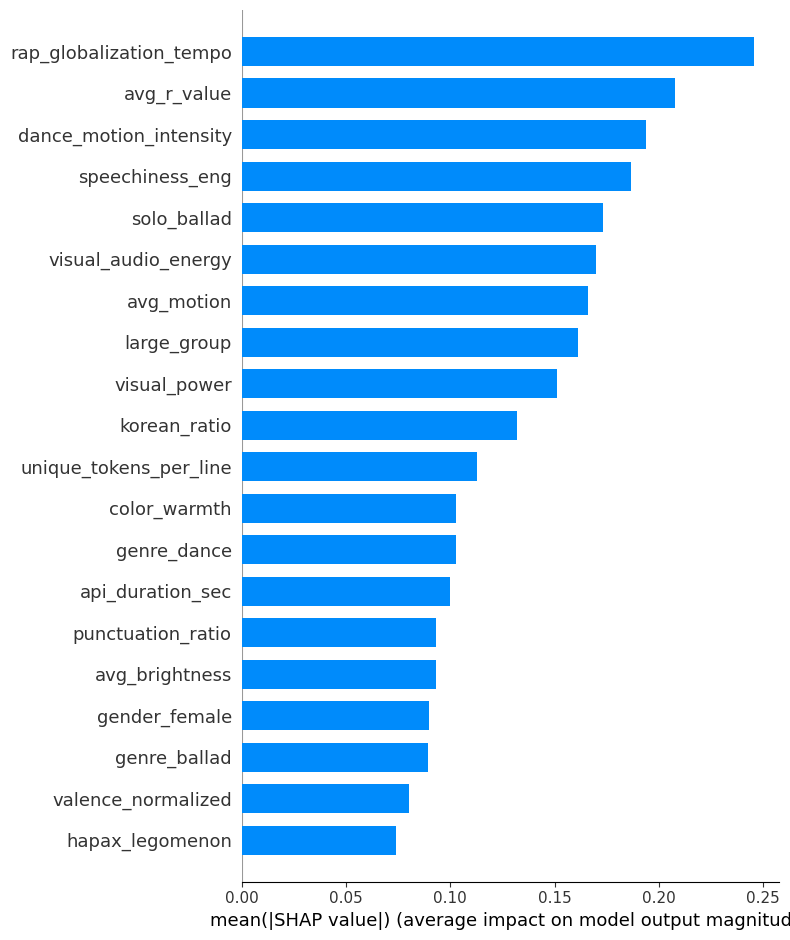

>> Saved: shap_bar_32.png

[SHAP 특징 중요도 상위 15위]
                feature  mean_shap
rap_globalization_tempo   0.245498
            avg_r_value   0.207829
 dance_motion_intensity   0.193815
        speechiness_eng   0.186720
            solo_ballad   0.173284
    visual_audio_energy   0.170051
             avg_motion   0.166275
            large_group   0.161026
           visual_power   0.151011
           korean_ratio   0.132002
 unique_tokens_per_line   0.112935
           color_warmth   0.102883
            genre_dance   0.102723
       api_duration_sec   0.099889
      punctuation_ratio   0.093329

[FP: 291개]  [FN: 187개]
>> Saved: fp_songs_32.csv, fn_songs_32.csv


In [43]:
# ── 추가 파생변수 3개 ──

# ① 대형 그룹 여부 (멤버 5명 이상)
drop_df['large_group'] = (
    (drop_df['is_group'] == 1) &
    (drop_df['member_count'] >= 5)
).astype(int)

# ② 고모션 × 댄스 장르
genre_dance_col = 'genre_댄스' if 'genre_댄스' in drop_df.columns else 'genre_dance'
drop_df['dance_motion_intensity'] = (
    drop_df['avg_motion'] *
    drop_df[genre_dance_col]
)

# ③ 콜라보레이션 여부
drop_df['is_collab'] = drop_df['songName'].str.contains(
    r'feat\.|feat |Feat\.|Feat |FEAT\.|FEAT |Prod\.|prod\.',
    case=False, regex=True
).astype(int)

print("[ 추가 파생변수 확인 ]")
print(f"large_group           - 대형그룹 곡 수 : {drop_df['large_group'].sum()}개")
print(f"dance_motion_intensity - mean          : {drop_df['dance_motion_intensity'].mean():.4f}")
print(f"is_collab             - 콜라보 곡 수   : {drop_df['is_collab'].sum()}개")

collab_hit = drop_df[['is_collab']].copy()
collab_hit['is_hit'] = (drop_df['api_view_count'] >= 1_000_000).astype(int)
print("\n[ is_collab × Hit 분포 ]")
print(pd.crosstab(collab_hit['is_collab'], collab_hit['is_hit'],
                  rownames=['is_collab'], colnames=['is_hit'], margins=True))

# ════════════════════════════════════════════════════════════
# 피처 정의 (29 + 3 = 32개)
# ════════════════════════════════════════════════════════════

FEATURES_NEW = FEATURES + ['large_group', 'dance_motion_intensity', 'is_collab']
FEATURES_NEW_EN = FEATURES_EN + ['large_group', 'dance_motion_intensity', 'is_collab']

FEATURES_NEW    = [f for f in FEATURES_NEW if f in drop_df.columns]
FEATURES_NEW_EN = FEATURES_NEW_EN[:len(FEATURES_NEW)]

X_new = drop_df[FEATURES_NEW].copy()
y     = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n사용 피처 수: {len(FEATURES_NEW)}개")

# ════════════════════════════════════════════════════════════
# CatBoost 교차검증
# ════════════════════════════════════════════════════════════

model = CatBoostClassifier(
    iterations=          772,
    learning_rate=       0.019113930760271142,
    depth=               4,
    l2_leaf_reg=         2.2251588705304837,
    bagging_temperature= 0.21762189130109433,
    random_strength=     0.15009890934829523,
    border_count=        142,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=0,
)

y_pred = cross_val_predict(model, X_new, y, cv=cv, method='predict')
y_prob = cross_val_predict(model, X_new, y, cv=cv, method='predict_proba')[:, 1]
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec  = recall_score(y, y_pred)
f1   = f1_score(y, y_pred)
auc  = roc_auc_score(y, y_prob)

print("\n[CatBoost 결과 - 3개 추가]")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"\nConfusion Matrix  →  TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("=" * 60)

print("\n[ 이전 결과와 비교 ]")
print(f"{'버전':<25} {'F1':>6} {'AUC':>6}  {'FP':>4} {'FN':>4}")
print("-" * 50)
print(f"{'기존 29개':<25} {'0.8175':>6} {'0.8224':>6}  {'293':>4} {'186':>4}")
print(f"{'신규 32개':<25} {f1:.4f} {auc:.4f}  {fp:>4} {fn:>4}")

# ════════════════════════════════════════════════════════════
# Confusion Matrix 시각화
# ════════════════════════════════════════════════════════════

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CatBoost 32개  |  F1={f1:.4f}  /  AUC={auc:.4f}", fontsize=10)
plt.tight_layout()
plt.savefig('catboost_32_cm.png', dpi=120)
plt.show()

# ════════════════════════════════════════════════════════════
# SHAP 분석
# ════════════════════════════════════════════════════════════

print("\n[SHAP 분석 중...]")
model.fit(X_new, y)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_new)

plt.figure(figsize=(10, 11))
shap.summary_plot(shap_values, X_new, feature_names=FEATURES_NEW_EN, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm_32.png', dpi=120)
plt.show()
print(">> Saved: shap_beeswarm_32.png")

plt.figure(figsize=(9, 10))
shap.summary_plot(shap_values, X_new, feature_names=FEATURES_NEW_EN, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_32.png', dpi=120)
plt.show()
print(">> Saved: shap_bar_32.png")

shap_importance_new = pd.DataFrame({
    'feature': FEATURES_NEW_EN,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\n[SHAP 특징 중요도 상위 15위]")
print(shap_importance_new.head(15).to_string(index=False))

# FP / FN
result_df = drop_df[['songName', 'artists', 'api_view_count', 'url']].copy()
result_df['y_true'] = y.values
result_df['y_pred'] = y_pred
result_df['y_prob'] = y_prob

fp_df = result_df[(result_df['y_true'] == 0) & (result_df['y_pred'] == 1)].sort_values('y_prob', ascending=False)
fn_df = result_df[(result_df['y_true'] == 1) & (result_df['y_pred'] == 0)].sort_values('y_prob', ascending=True)

print(f"\n[FP: {len(fp_df)}개]  [FN: {len(fn_df)}개]")

fp_df.to_csv('fp_songs_32.csv', index=False)
fn_df.to_csv('fn_songs_32.csv', index=False)
print(">> Saved: fp_songs_32.csv, fn_songs_32.csv")